/tmp/ipykernel_1656/1440544077.py:22: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  months = pd.date_range(start="2023-01-01", periods=12, freq="M")


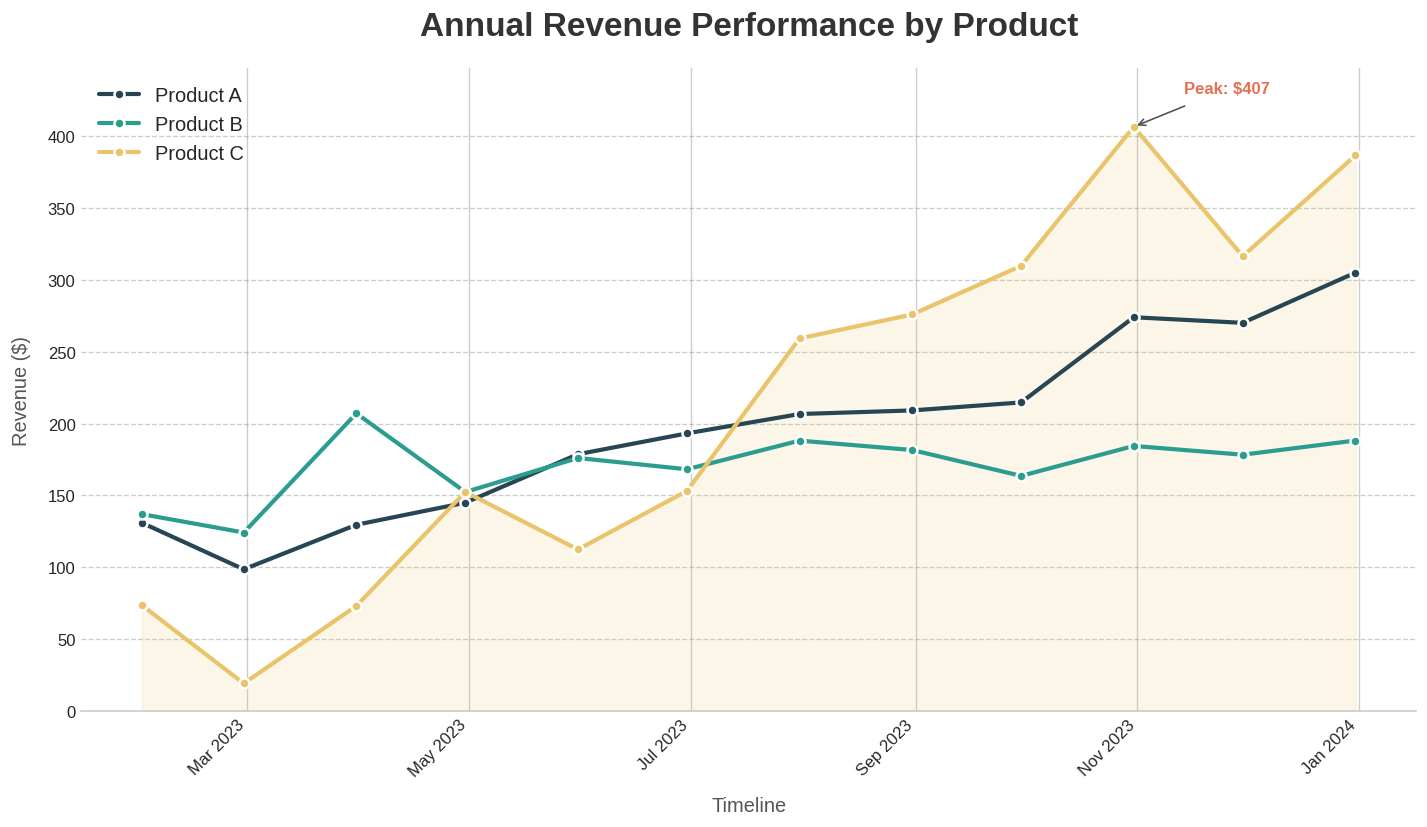

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

# 1. Setup Modern Aesthetics
# --------------------------
# We use 'seaborn-v0_8-whitegrid' for a clean background, or 'seaborn-v0_8-darkgrid'
try:
    plt.style.use('seaborn-v0_8-whitegrid')
except:
    # Fallback for older seaborn versions
    plt.style.use('seaborn-whitegrid')

# Set a custom color palette
colors = ["#264653", "#2A9D8F", "#E9C46A", "#F4A261", "#E76F51"]
sns.set_palette(sns.color_palette(colors))

# 2. Create Dummy Data
# --------------------
# We will simulate Monthly Revenue for 3 different products over a year
months = pd.date_range(start="2023-01-01", periods=12, freq="M")
product_a = np.linspace(100, 300, 12) + np.random.normal(0, 15, 12)
product_b = np.linspace(150, 200, 12) + np.random.normal(0, 20, 12)
product_c = np.linspace(50, 400, 12) + np.random.normal(0, 30, 12)

# Create a DataFrame for easier plotting
df = pd.DataFrame({
    'Month': months,
    'Product A': product_a,
    'Product B': product_b,
    'Product C': product_c
})

# Melt the dataframe to "long format" which is ideal for seaborn/matplotlib loops
df_long = df.melt('Month', var_name='Product', value_name='Revenue')

# 3. Initialize the Figure
# ------------------------
plt.figure(figsize=(12, 7), dpi=120) # High DPI for crisp text
ax = plt.gca()

# 4. Plotting the Lines and Areas
# -------------------------------
# We use a loop to customize markers and fills per line
for i, product in enumerate(df.columns[1:]):
    # Plot the line
    ax.plot(df['Month'], df[product], 
            linewidth=2.5, 
            marker='o', 
            markersize=6, 
            markeredgecolor='white',
            markeredgewidth=1.5,
            label=product,
            color=colors[i % len(colors)])
    
    # Add a subtle fill under the line (optional, for 'Product C' we make it distinct)
    if product == 'Product C':
        ax.fill_between(df['Month'], df[product], alpha=0.15, color=colors[i % len(colors)])

# 5. Customizing the Axes and Grid
# --------------------------------
# Remove top and right spines for a cleaner look
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_visible(False)

# Customize grid
ax.grid(axis='y', linestyle='--', alpha=0.4, color='gray')

# Set Y-axis to start at 0 for honesty in data viz
ax.set_ylim(0, max(df_long['Revenue']) * 1.1)

# Format X-axis dates nicely
import matplotlib.dates as mdates
ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
plt.xticks(rotation=45, ha='right')

# 6. Adding Titles and Labels
# ---------------------------
plt.title("Annual Revenue Performance by Product", 
          fontsize=20, 
          fontweight='bold', 
          color='#333333', 
          pad=20)

plt.xlabel("Timeline", fontsize=12, color='#555555', labelpad=10)
plt.ylabel("Revenue ($)", fontsize=12, color='#555555', labelpad=10)

# 7. Adding Annotations (The "Pro" Touch)
# ---------------------------------------
# Highlighting the peak performance of Product C
max_val = df['Product C'].max()
max_date = df.loc[df['Product C'].idxmax(), 'Month']

ax.annotate(f'Peak: ${max_val:.0f}', 
            xy=(max_date, max_val), 
            xytext=(30, 20), 
            textcoords='offset points',
            bbox=dict(boxstyle='round,pad=0.5', fc='white', alpha=0.8, edgecolor='none'),
            arrowprops=dict(arrowstyle='->', connectionstyle='arc3,rad=0', color='#555555'),
            fontsize=10, 
            fontweight='bold',
            color='#E76F51')

# 8. Legend
# ---------
plt.legend(frameon=False, fontsize=12, loc='upper left')

# 9. Final Layout Adjustment
# --------------------------
plt.tight_layout()

# Show the plot
plt.show()